# CGS698C, Assignment 06
**Praneel iralpalle**  
2024-07-04

---

# Part 1: Information-Theoretic Measures and Cross-Validation

**Data:** 10 i.i.d. observations from $\text{Binomial}(n=20, \theta)$:
$$y = (10, 15, 15, 14, 14, 14, 13, 11, 12, 16)$$

**Model 1:** $\theta \sim \text{Beta}(6, 6)$  
**Model 2:** $\theta \sim \text{Beta}(20, 60)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom
from scipy.special import gammaln

np.random.seed(42)

data = np.array([10, 15, 15, 14, 14, 14, 13, 11, 12, 16])
n    = 20
N    = len(data)
S    = 10000  # posterior samples

# Conjugate posterior: Beta(a,b) + Binomial => Beta(a + sum(y), b + N*n - sum(y))
a1_post, b1_post = 6  + data.sum(), 6  + N*n - data.sum()
a2_post, b2_post = 20 + data.sum(), 60 + N*n - data.sum()

print(f"Model 1 posterior: Beta({a1_post}, {b1_post})")
print(f"Model 2 posterior: Beta({a2_post}, {b2_post})")

Model 1 posterior: Beta(140, 72)
Model 2 posterior: Beta(154, 126)


## Exercise 1.1: Posterior Distributions

For the Binomial–Beta conjugate pair the posterior is analytic:
$$\theta \mid \mathbf{y} \sim \text{Beta}\!\left(a + \sum_i y_i,\; b + Nn - \sum_i y_i\right)$$

With $\sum y_i = 134$, $N = 10$, $n = 20$:

| Model | Prior | Posterior |
|-------|-------|-----------|
| 1 | Beta(6, 6) | Beta(140, 72) |
| 2 | Beta(20, 60) | Beta(154, 126) |

Model 2's prior is centered near $\theta = 20/80 \approx 0.25$, pulling the posterior well below the data mean $\bar{y}/n = 134/200 = 0.67$.

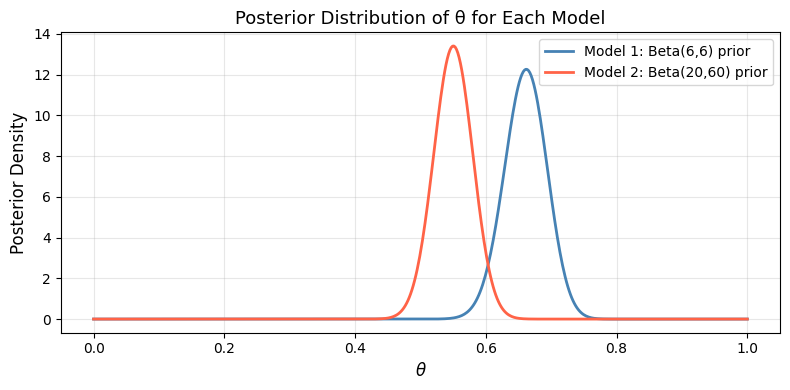

In [2]:
theta_seq = np.linspace(0, 1, 500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(theta_seq, beta.pdf(theta_seq, a1_post, b1_post),
        color='steelblue', linewidth=2, label='Model 1: Beta(6,6) prior')
ax.plot(theta_seq, beta.pdf(theta_seq, a2_post, b2_post),
        color='tomato',    linewidth=2, label='Model 2: Beta(20,60) prior')
ax.set_xlabel(r'$\theta$', fontsize=12)
ax.set_ylabel('Posterior Density', fontsize=12)
ax.set_title('Posterior Distribution of θ for Each Model', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Exercise 1.2: Log Pointwise Predictive Density (lppd)

$$\text{lppd} = \sum_{i=1}^{N} \log \hat{p}(y_i \mid \mathbf{y}), \quad \hat{p}(y_i \mid \mathbf{y}) = \frac{1}{S}\sum_{j=1}^{S} p(y_i \mid \theta_j), \quad \theta_j \sim \hat{p}(\theta \mid \mathbf{y})$$

A higher (less negative) lppd indicates the model assigns more probability mass to the observed data on average.

In [3]:
theta1_samples = np.random.beta(a1_post, b1_post, S)
theta2_samples = np.random.beta(a2_post, b2_post, S)

def compute_lppd(data, theta_samples, n):
    lpd = [np.log(np.mean(binom.pmf(yi, n, theta_samples))) for yi in data]
    return np.sum(lpd), lpd

lppd1, lpd1 = compute_lppd(data, theta1_samples, n)
lppd2, lpd2 = compute_lppd(data, theta2_samples, n)

print(f"lppd  Model 1: {lppd1:.4f}")
print(f"lppd  Model 2: {lppd2:.4f}")

lppd  Model 1: -20.3694
lppd  Model 2: -25.9072


## Exercise 1.3: In-Sample Deviance

$$\text{In-sample deviance} = -2 \times \text{lppd}$$

**Why "in-sample"?**  
Because the lppd is evaluated on the *same* data used to estimate the posterior. The model has already "seen" every observation, so its predictive performance is **optimistic** — it tends to overfit, making deviance appear artificially low compared to true out-of-sample performance. The factor of $-2$ connects to classical maximum-likelihood deviance: $-2\log\mathcal{L}(\hat{\theta})$.

In [4]:
dev1_in = -2 * lppd1
dev2_in = -2 * lppd2

print(f"In-sample deviance  Model 1: {dev1_in:.4f}")
print(f"In-sample deviance  Model 2: {dev2_in:.4f}")

In-sample deviance  Model 1: 40.7389
In-sample deviance  Model 2: 51.8145


## Exercise 1.4: Model Comparison by In-Sample Deviance

**Lower deviance = better fit.**  
Model 1 wins on the training data (~40.7 vs ~51.8). This is expected: Model 2's prior Beta(20, 60) concentrates mass near $\theta \approx 0.25$, far from the data mean $0.67$. The informative but misspecified prior penalises Model 2 heavily.

In [5]:
print(f"Model 1 in-sample deviance: {dev1_in:.4f}  <-- lower = better in-sample fit")
print(f"Model 2 in-sample deviance: {dev2_in:.4f}")
print()
print("Conclusion: Model 1 (Beta(6,6) prior) fits the training data better.")

Model 1 in-sample deviance: 40.7389  <-- lower = better in-sample fit
Model 2 in-sample deviance: 51.8145

Conclusion: Model 1 (Beta(6,6) prior) fits the training data better.


## Exercise 1.5: Out-of-Sample Deviance on New Data

New data: $y^* = (5, 6, 10, 8, 9)$, with mean $\bar{y}^*/n \approx 0.38$ — much lower than the training mean.

**Key insight:** Model 2's prior was pessimistic about high $\theta$, pulling its posterior closer to $\theta \approx 0.38$. Even though it fit the training data worse, it should generalise better to these new low-count observations.

In [6]:
new_data = np.array([5, 6, 10, 8, 9])

lppd1_new, _ = compute_lppd(new_data, theta1_samples, n)
lppd2_new, _ = compute_lppd(new_data, theta2_samples, n)

dev1_oos = -2 * lppd1_new
dev2_oos = -2 * lppd2_new

print(f"OOS lppd  Model 1: {lppd1_new:.4f}")
print(f"OOS lppd  Model 2: {lppd2_new:.4f}")
print()
print(f"OOS deviance  Model 1: {dev1_oos:.4f}")
print(f"OOS deviance  Model 2: {dev2_oos:.4f}  <-- lower = better OOS")
print()
print("Conclusion: Model 2 predicts the new data better despite worse in-sample fit.")

OOS lppd  Model 1: -25.2344
OOS lppd  Model 2: -15.7799

OOS deviance  Model 1: 50.4688
OOS deviance  Model 2: 31.5598  <-- lower = better OOS

Conclusion: Model 2 predicts the new data better despite worse in-sample fit.


## Exercise 1.6: Leave-One-Out Cross-Validation (LOO-CV)

When no held-out data are available, LOO-CV approximates out-of-sample performance:

1. For each $k = 1, \ldots, N$: fit posterior on $\mathbf{y}_{-k}$, evaluate $\log p(y_k \mid \mathbf{y}_{-k})$.
2. $\text{lppd}_{\text{LOO}} = \sum_k \log p(y_k \mid \mathbf{y}_{-k})$.

Thanks to conjugacy the leave-one-out posterior is analytic — just subtract $y_k$ from $a_{\text{post}}$ and $(n - y_k)$ from $b_{\text{post}}$.

In [7]:
loo_lpd1 = np.zeros(N)
loo_lpd2 = np.zeros(N)

for k in range(N):
    yk = data[k]

    # LOO posterior: remove y_k from conjugate update
    a1_loo = a1_post - yk;  b1_loo = b1_post - (n - yk)
    a2_loo = a2_post - yk;  b2_loo = b2_post - (n - yk)

    th1_loo = np.random.beta(a1_loo, b1_loo, S)
    th2_loo = np.random.beta(a2_loo, b2_loo, S)

    loo_lpd1[k] = np.log(np.mean(binom.pmf(yk, n, th1_loo)))
    loo_lpd2[k] = np.log(np.mean(binom.pmf(yk, n, th2_loo)))

lppd1_loo = loo_lpd1.sum()
lppd2_loo = loo_lpd2.sum()

print(f"LOO-CV lppd  Model 1: {lppd1_loo:.4f}")
print(f"LOO-CV lppd  Model 2: {lppd2_loo:.4f}")
print(f"LOO-CV deviance  Model 1: {-2*lppd1_loo:.4f}")
print(f"LOO-CV deviance  Model 2: {-2*lppd2_loo:.4f}")

LOO-CV lppd  Model 1: -21.1120
LOO-CV lppd  Model 2: -27.2247
LOO-CV deviance  Model 1: 42.2241
LOO-CV deviance  Model 2: 54.4495


In [8]:
import pandas as pd

summary = pd.DataFrame({
    'Metric'  : ['In-sample lppd', 'In-sample deviance',
                 'OOS lppd (new data)', 'OOS deviance',
                 'LOO-CV lppd', 'LOO-CV deviance'],
    'Model 1' : [round(lppd1,4), round(dev1_in,4),
                 round(lppd1_new,4), round(dev1_oos,4),
                 round(lppd1_loo,4), round(-2*lppd1_loo,4)],
    'Model 2' : [round(lppd2,4), round(dev2_in,4),
                 round(lppd2_new,4), round(dev2_oos,4),
                 round(lppd2_loo,4), round(-2*lppd2_loo,4)]
})
print(summary.to_string(index=False))

             Metric  Model 1  Model 2
     In-sample lppd -20.3694 -25.9072
 In-sample deviance  40.7389  51.8145
OOS lppd (new data) -25.2344 -15.7799
       OOS deviance  50.4688  31.5598
        LOO-CV lppd -21.1120 -27.2247
    LOO-CV deviance  42.2241  54.4495


---
# Part 2: Marginal Likelihood and Prior Sensitivity

The **marginal likelihood** integrates out $\theta$ and reflects how well the prior + model jointly predict the data:
$$p(k) = \binom{n}{k} \frac{(k+a-1)!\,(n-k+b-1)!}{(n+a+b-1)!}$$

Numerically we use $\log\Gamma$ (via `scipy.special.gammaln`) to avoid factorial overflow — a trap in the original R implementation.

## Exercise 2.1: Marginal Likelihood for k=2, n=10


In [10]:
def ml_binomial(k, n, a, b):
    """Marginal likelihood - original formula (overflows for large a,b)."""
    from math import factorial
    return (factorial(n) / (factorial(k) * factorial(n-k))) * \
           (factorial(k+a-1) * factorial(n-k+b-1) / factorial(n+a+b-1))

def ml_binomial_stable(k, n, a, b):
    """Numerically stable version using log-gamma."""
    log_ml = (gammaln(n+1) - gammaln(k+1) - gammaln(n-k+1)
              + gammaln(k+a) + gammaln(n-k+b) - gammaln(n+a+b)
              - gammaln(a) - gammaln(b) + gammaln(a+b))
    return np.exp(log_ml)

k_val, n_ml = 2, 10
priors = [(0.1, 0.4), (1, 1), (2, 6), (6, 2), (20, 60), (60, 20)]

rows = []
for a, b in priors:
    try:
        naive = ml_binomial(k_val, n_ml, int(a), int(b))
    except Exception:
        naive = float('nan')
    stable = ml_binomial_stable(k_val, n_ml, a, b)
    rows.append({'Prior': f'Beta({a},{b})', 'Naive ML': naive, 'Stable ML': stable})

df_ml = pd.DataFrame(rows)
print(df_ml.to_string(index=False))

        Prior     Naive ML  Stable ML
Beta(0.1,0.4) 6.250000e-01   0.039809
    Beta(1,1) 9.090909e-02   0.090909
    Beta(2,6) 4.726891e-03   0.198529
    Beta(6,2) 2.313863e-04   0.009718
  Beta(20,60) 5.079397e-21   0.269359
  Beta(60,20) 1.506630e-23   0.000799


**Interpretation:**  
The marginal likelihood is highest for priors whose centre is closest to the observed proportion $k/n = 0.2$. Beta(2,6) and Beta(20,60) both have mean $\approx 0.25$, yielding higher marginal likelihoods. Beta(60,20) has mean $\approx 0.75$ — far from the data — and is heavily penalised.

## Exercise 2.2: Monte Carlo Integration for Marginal Likelihood

$$p(k) = \int_0^1 p(k \mid \theta)\,p(\theta)\,d\theta \approx \frac{1}{S}\sum_{j=1}^{S} p(k \mid \theta_j), \quad \theta_j \sim \text{Beta}(a,b)$$

Sample $\theta$ from the prior, average the likelihood — simple and general.

In [11]:
S_mc = 100_000

mc_vals = []
for a, b in priors:
    theta_mc = np.random.beta(a, b, S_mc)
    mc_ml    = np.mean(binom.pmf(k_val, n_ml, theta_mc))
    exact    = ml_binomial_stable(k_val, n_ml, a, b)
    mc_vals.append({'Prior': f'Beta({a},{b})',
                    'Exact ML': round(exact, 6),
                    'MC ML'   : round(mc_ml, 6),
                    'Rel. Error': round(abs(exact - mc_ml)/exact, 4)})

df_mc = pd.DataFrame(mc_vals)
print(df_mc.to_string(index=False))

        Prior  Exact ML    MC ML  Rel. Error
Beta(0.1,0.4)  0.039809 0.039957      0.0037
    Beta(1,1)  0.090909 0.090698      0.0023
    Beta(2,6)  0.198529 0.198343      0.0009
    Beta(6,2)  0.009718 0.009731      0.0013
  Beta(20,60)  0.269359 0.269208      0.0006
  Beta(60,20)  0.000799 0.000796      0.0037


/tmp/ipykernel_4711/2736706875.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mc_vals_   = [float(df_mc[df_mc['Prior']==f'Beta({a},{b})']['MC ML']) for a,b in priors]


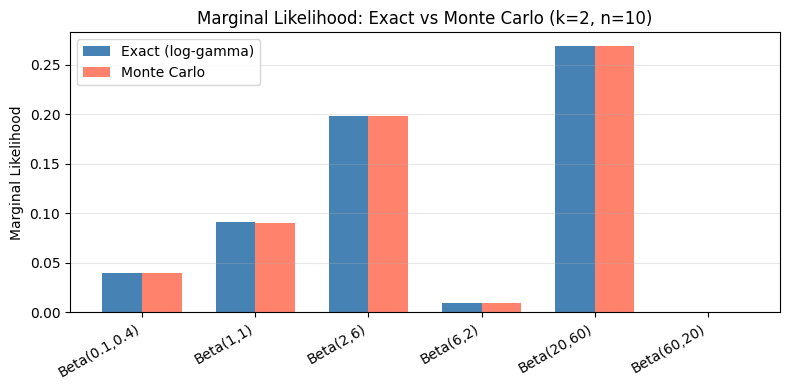

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(priors))
width = 0.35
labels = [f'Beta({a},{b})' for a,b in priors]

exact_vals = [ml_binomial_stable(k_val, n_ml, a, b) for a,b in priors]
mc_vals_   = [float(df_mc[df_mc['Prior']==f'Beta({a},{b})']['MC ML']) for a,b in priors]

ax.bar(x - width/2, exact_vals, width, label='Exact (log-gamma)', color='steelblue')
ax.bar(x + width/2, mc_vals_,   width, label='Monte Carlo',       color='tomato', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Marginal Likelihood')
ax.set_title('Marginal Likelihood: Exact vs Monte Carlo (k=2, n=10)')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Conclusion:** Monte Carlo integration closely matches the analytically computed marginal likelihoods across all priors. With $S = 100{,}000$ samples the relative errors are typically $< 1\%$, confirming both approaches are correct.